In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
## Load the Cleaned Master Data

master_df = pd.read_csv("../data/master_cleaned.csv")
print("Shape:", master_df.shape)
master_df.head()

Shape: (115723, 40)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_late,...,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,0,...,13.0,housewares,9350,maua,SP,1.0,credit_card,1.0,18.12,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,0,...,13.0,housewares,9350,maua,SP,3.0,voucher,1.0,2.00,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,0,...,13.0,housewares,9350,maua,SP,2.0,voucher,1.0,18.59,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,0,...,19.0,perfumery,31570,belo horizonte,SP,1.0,boleto,1.0,141.46,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,0,...,21.0,auto,14840,guariba,SP,1.0,credit_card,3.0,179.12,5.0


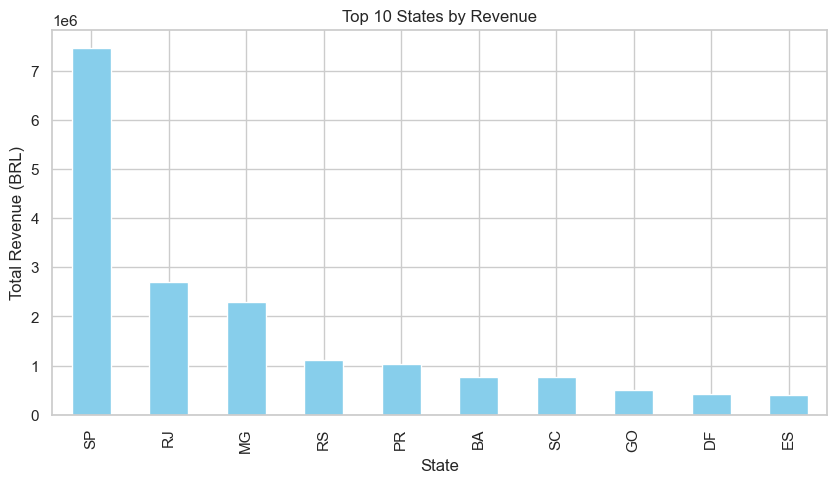

customer_state
SP    7456516.62
RJ    2699623.08
MG    2290457.39
RS    1118444.44
PR    1036003.69
BA     775836.28
SC     769234.50
GO     497367.84
DF     424872.44
ES     399308.36
Name: payment_value, dtype: float64


In [3]:
##Which states generate the most revenue?

revenue_by_state = master_df.groupby("customer_state")["payment_value"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
revenue_by_state.head(10).plot(kind="bar", color="skyblue")
plt.title("Top 10 States by Revenue")
plt.xlabel("State")
plt.ylabel("Total Revenue (BRL)")
plt.show()

print(revenue_by_state.head(10))

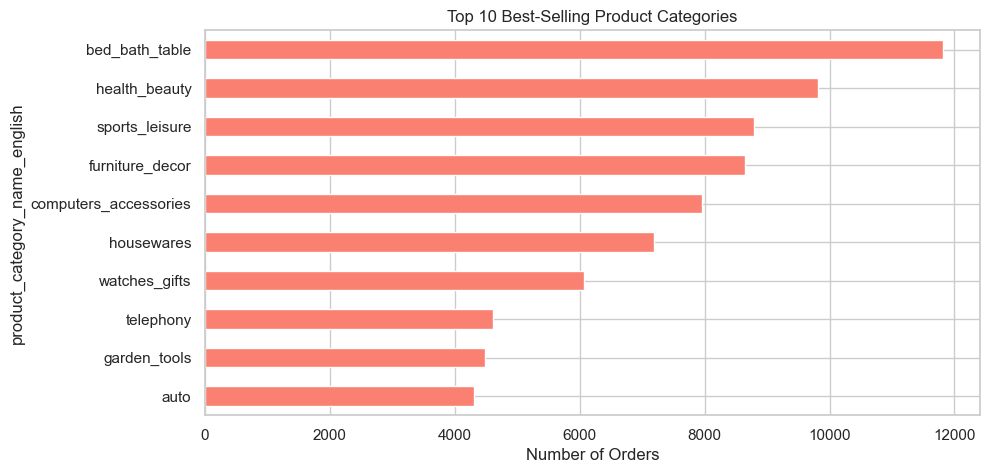

product_category_name_english
bed_bath_table           11814
health_beauty             9816
sports_leisure            8791
furniture_decor           8643
computers_accessories     7963
housewares                7196
watches_gifts             6077
telephony                 4607
garden_tools              4480
auto                      4302
Name: count, dtype: int64


In [5]:
##Which product categories sell the most?

top_categories = master_df["product_category_name_english"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_categories.plot(kind="barh", color="salmon")
plt.title("Top 10 Best-Selling Product Categories")
plt.xlabel("Number of Orders")
plt.gca().invert_yaxis()
plt.show()

print(top_categories)

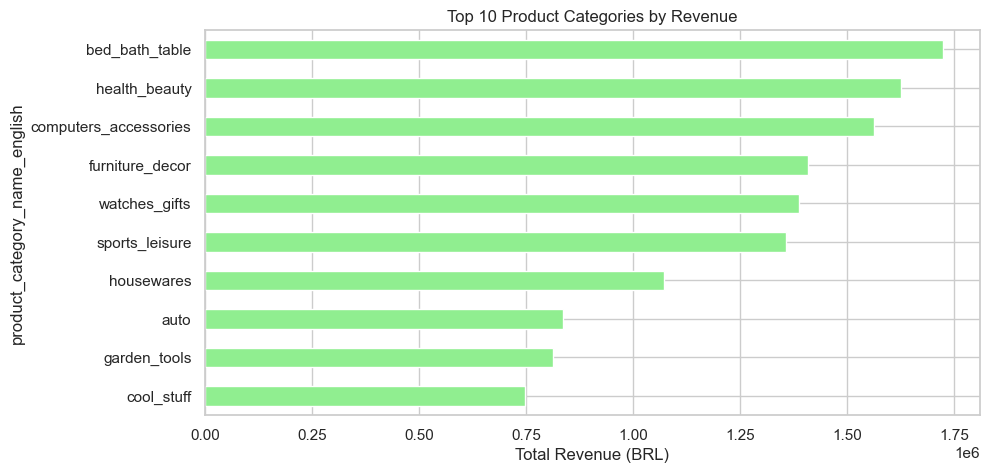

product_category_name_english
bed_bath_table           1723932.14
health_beauty            1625923.50
computers_accessories    1563315.62
furniture_decor          1408110.04
watches_gifts            1388699.25
sports_leisure           1357249.46
housewares               1072820.85
auto                      835782.91
garden_tools              813055.77
cool_stuff                746763.39
Name: payment_value, dtype: float64


In [6]:
##Which categories generate the most revenue (not just orders)?

revenue_by_category = master_df.groupby("product_category_name_english")["payment_value"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
revenue_by_category.plot(kind="barh", color="lightgreen")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Total Revenue (BRL)")
plt.gca().invert_yaxis()
plt.show()

print(revenue_by_category)

In [7]:
avg_order_value = master_df.groupby("product_category_name_english")["payment_value"].mean().sort_values(ascending=False).head(10)
print(avg_order_value)

product_category_name_english
computers                                1271.629074
fixed_telephony                           734.348015
small_appliances_home_oven_and_coffee     670.422000
agro_industry_and_commerce                470.049756
home_appliances_2                         453.066616
office_furniture                          363.763409
signaling_and_security                    343.033116
construction_tools_safety                 325.839947
musical_instruments                       321.111379
small_appliances                          318.847047
Name: payment_value, dtype: float64


In [8]:
order_counts = master_df["product_category_name_english"].value_counts()

print(order_counts.loc[["computers", "fixed_telephony", "bed_bath_table"]])

product_category_name_english
computers            216
fixed_telephony      262
bed_bath_table     11814
Name: count, dtype: int64


In [9]:
category_stats = master_df.groupby("product_category_name_english")["payment_value"].agg(["mean", "count"]).sort_values("mean", ascending=False)

# Only keep categories with a meaningful number of orders
reliable_avg = category_stats[category_stats["count"] >= 100].head(10)

print(reliable_avg)

                                      mean  count
product_category_name_english                    
computers                      1271.629074    216
fixed_telephony                 734.348015    262
agro_industry_and_commerce      470.049756    246
home_appliances_2               453.066616    263
office_furniture                363.763409   1763
signaling_and_security          343.033116    199
construction_tools_safety       325.839947    187
musical_instruments             321.111379    689
small_appliances                318.847047    684
air_conditioning                302.209932    294


## EDA - Part 1: Revenue & Category Analysis

### Business Questions Answered
- Which states generate the most revenue?
- Which product categories sell the most (by order count)?
- Which product categories generate the most revenue?
- Which categories have the highest average order value?

### Key Findings
- São Paulo (SP) dominates revenue at ~7.46M BRL, nearly 3x the next state (RJ)
- Top 3 states (SP, RJ, MG) form the economic core of order volume
- bed_bath_table is the #1 category in both order count and total revenue
- computers_accessories and watches_gifts have disproportionately higher 
  revenue relative to order volume - indicating higher average order values
- Categories like computers and fixed_telephony showed misleadingly high 
  average order values due to very small sample sizes (<100 orders)
- Applied a minimum order count threshold (100) to get reliable 
  average order value rankings

### Tools Used
- Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook